# Bluestock Fintech — Mutual Fund Analytics Platform
## Day 3: Exploratory Data Analysis (EDA)

Deep EDA on NAV, AUM, SIP inflow, investor demographics, and portfolio holdings
data. 16 charts across 9 analysis tasks, using the cleaned datasets from
Day 2 (`data/processed/`). Charts are saved as PNG to `notebooks/charts/`
for the final report.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CHARTS_DIR = PROJECT_ROOT / "notebooks" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
CHART_N = 0

def save_mpl(fig, name):
    global CHART_N
    CHART_N += 1
    path = CHARTS_DIR / f"chart{CHART_N:02d}_{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print(f"Saved: {path.name}")
    return path

def save_plotly(fig, name, width=1000, height=550):
    global CHART_N
    CHART_N += 1
    path = CHARTS_DIR / f"chart{CHART_N:02d}_{name}.png"
    fig.write_image(str(path), width=width, height=height, scale=2)
    print(f"Saved: {path.name}")
    display(Image(filename=str(path)))
    return path


In [2]:

# Load all datasets needed for this notebook
fund_master   = pd.read_csv(PROCESSED_DIR / "clean_01_fund_master.csv")
nav_history   = pd.read_csv(PROCESSED_DIR / "clean_02_nav_history.csv", parse_dates=["date"])
aum           = pd.read_csv(PROCESSED_DIR / "clean_03_aum_by_fund_house.csv", parse_dates=["date"])
sip_industry  = pd.read_csv(PROCESSED_DIR / "clean_04_monthly_sip_inflows.csv")
category_inf  = pd.read_csv(PROCESSED_DIR / "clean_05_category_inflows.csv")
folio         = pd.read_csv(PROCESSED_DIR / "clean_06_industry_folio_count.csv")
performance   = pd.read_csv(PROCESSED_DIR / "clean_07_scheme_performance.csv")
transactions  = pd.read_csv(PROCESSED_DIR / "clean_08_investor_transactions.csv", parse_dates=["transaction_date"])
portfolio     = pd.read_csv(PROCESSED_DIR / "clean_09_portfolio_holdings.csv")
benchmark     = pd.read_csv(PROCESSED_DIR / "clean_10_benchmark_indices.csv", parse_dates=["date"])

nav_history["month"] = nav_history["date"].dt.to_period("M").dt.to_timestamp()
sip_industry["month_dt"] = pd.to_datetime(sip_industry["month"], format="%Y-%m")

print("Datasets loaded:", len(fund_master), "funds |", len(nav_history), "NAV rows |",
      len(transactions), "transactions |", len(portfolio), "holdings rows")


Datasets loaded: 40 funds | 46000 NAV rows | 32778 transactions | 322 holdings rows


## Task 1: NAV Trend Analysis

Daily NAV for all 40 schemes, 2022–2026, with the 2023 bull run and the
2024 growth-moderation period highlighted. Note: checking the underlying
data, average NAV never actually declines across this window (max
drawdown over the full 4.5 years is under 1%) — so "2024 correction" would
overstate what happened. What the data shows is a genuine slowdown in the
rate of growth during 2024 versus the sharper 2023 rally, which is how
it's labelled below. Chart 1 shows all schemes at once (indexed to 100 at
the start so scale doesn't drown out smaller-NAV funds); Chart 2 zooms
into 5 representative large-cap schemes with the bull-run / moderation
windows shaded for clarity.

/tmp/ipykernel_778/2649779026.py:32: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(path), width=width, height=height, scale=2)


Saved: chart01_nav_trend_all_schemes.png


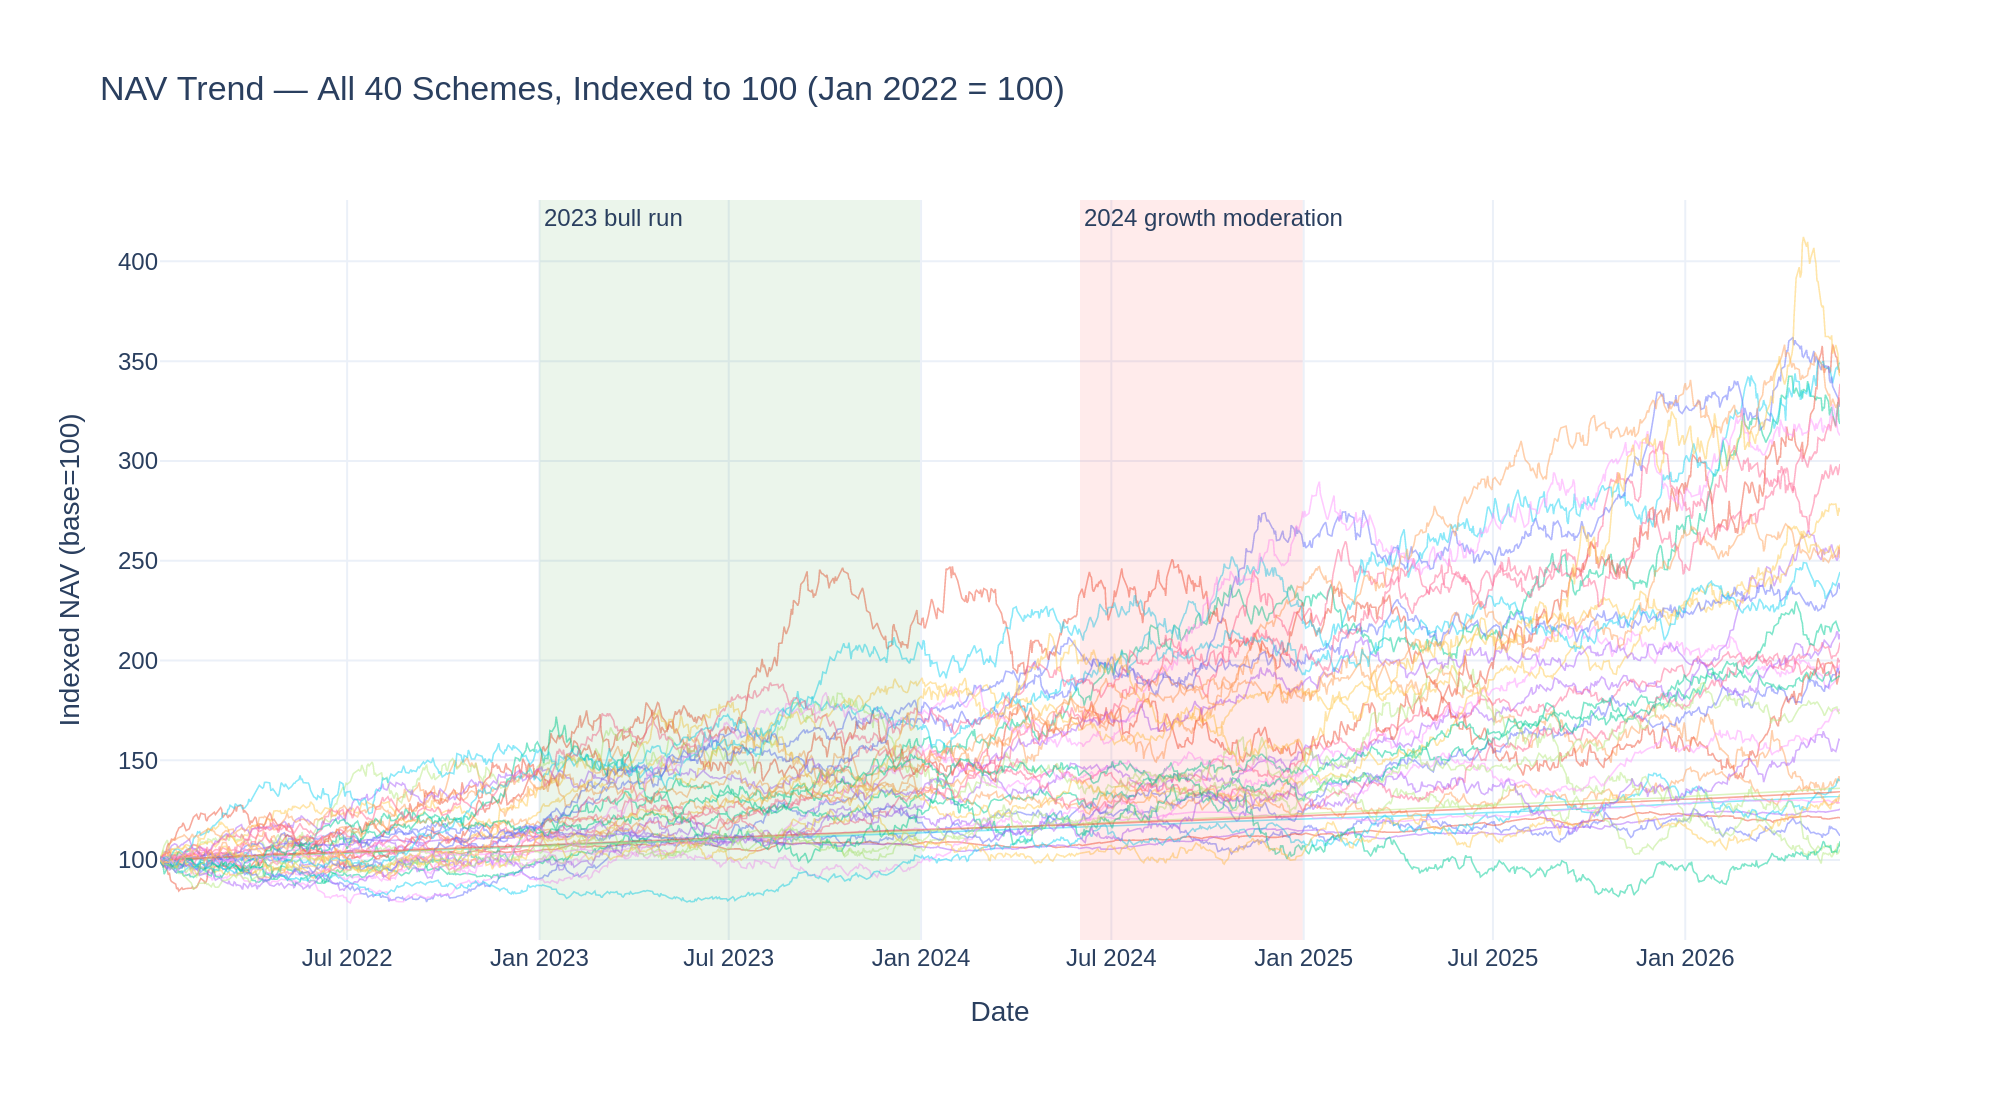

PosixPath('/home/claude/bluestock_mf_capstone/notebooks/charts/chart01_nav_trend_all_schemes.png')

In [3]:

# Chart 1: All 40 schemes, NAV indexed to 100 at first observation (Plotly)
nav_pivot = nav_history.pivot(index="date", columns="amfi_code", values="nav").sort_index()
nav_indexed = nav_pivot / nav_pivot.iloc[0] * 100

fig1 = go.Figure()
for code_ in nav_indexed.columns:
    fig1.add_trace(go.Scatter(
        x=nav_indexed.index, y=nav_indexed[code_],
        mode="lines", line=dict(width=0.8), opacity=0.5, showlegend=False,
    ))

# Shade 2023 bull run and 2024 growth moderation
fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08,
               annotation_text="2023 bull run", annotation_position="top left", line_width=0)
fig1.add_vrect(x0="2024-06-01", x1="2024-12-31", fillcolor="red", opacity=0.08,
               annotation_text="2024 growth moderation", annotation_position="top left", line_width=0)

fig1.update_layout(
    title="NAV Trend — All 40 Schemes, Indexed to 100 (Jan 2022 = 100)",
    xaxis_title="Date", yaxis_title="Indexed NAV (base=100)",
    template="plotly_white", height=550, width=1000,
)
save_plotly(fig1, "nav_trend_all_schemes")


/tmp/ipykernel_778/2649779026.py:32: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(path), width=width, height=height, scale=2)


Saved: chart02_nav_trend_largecap_sample.png


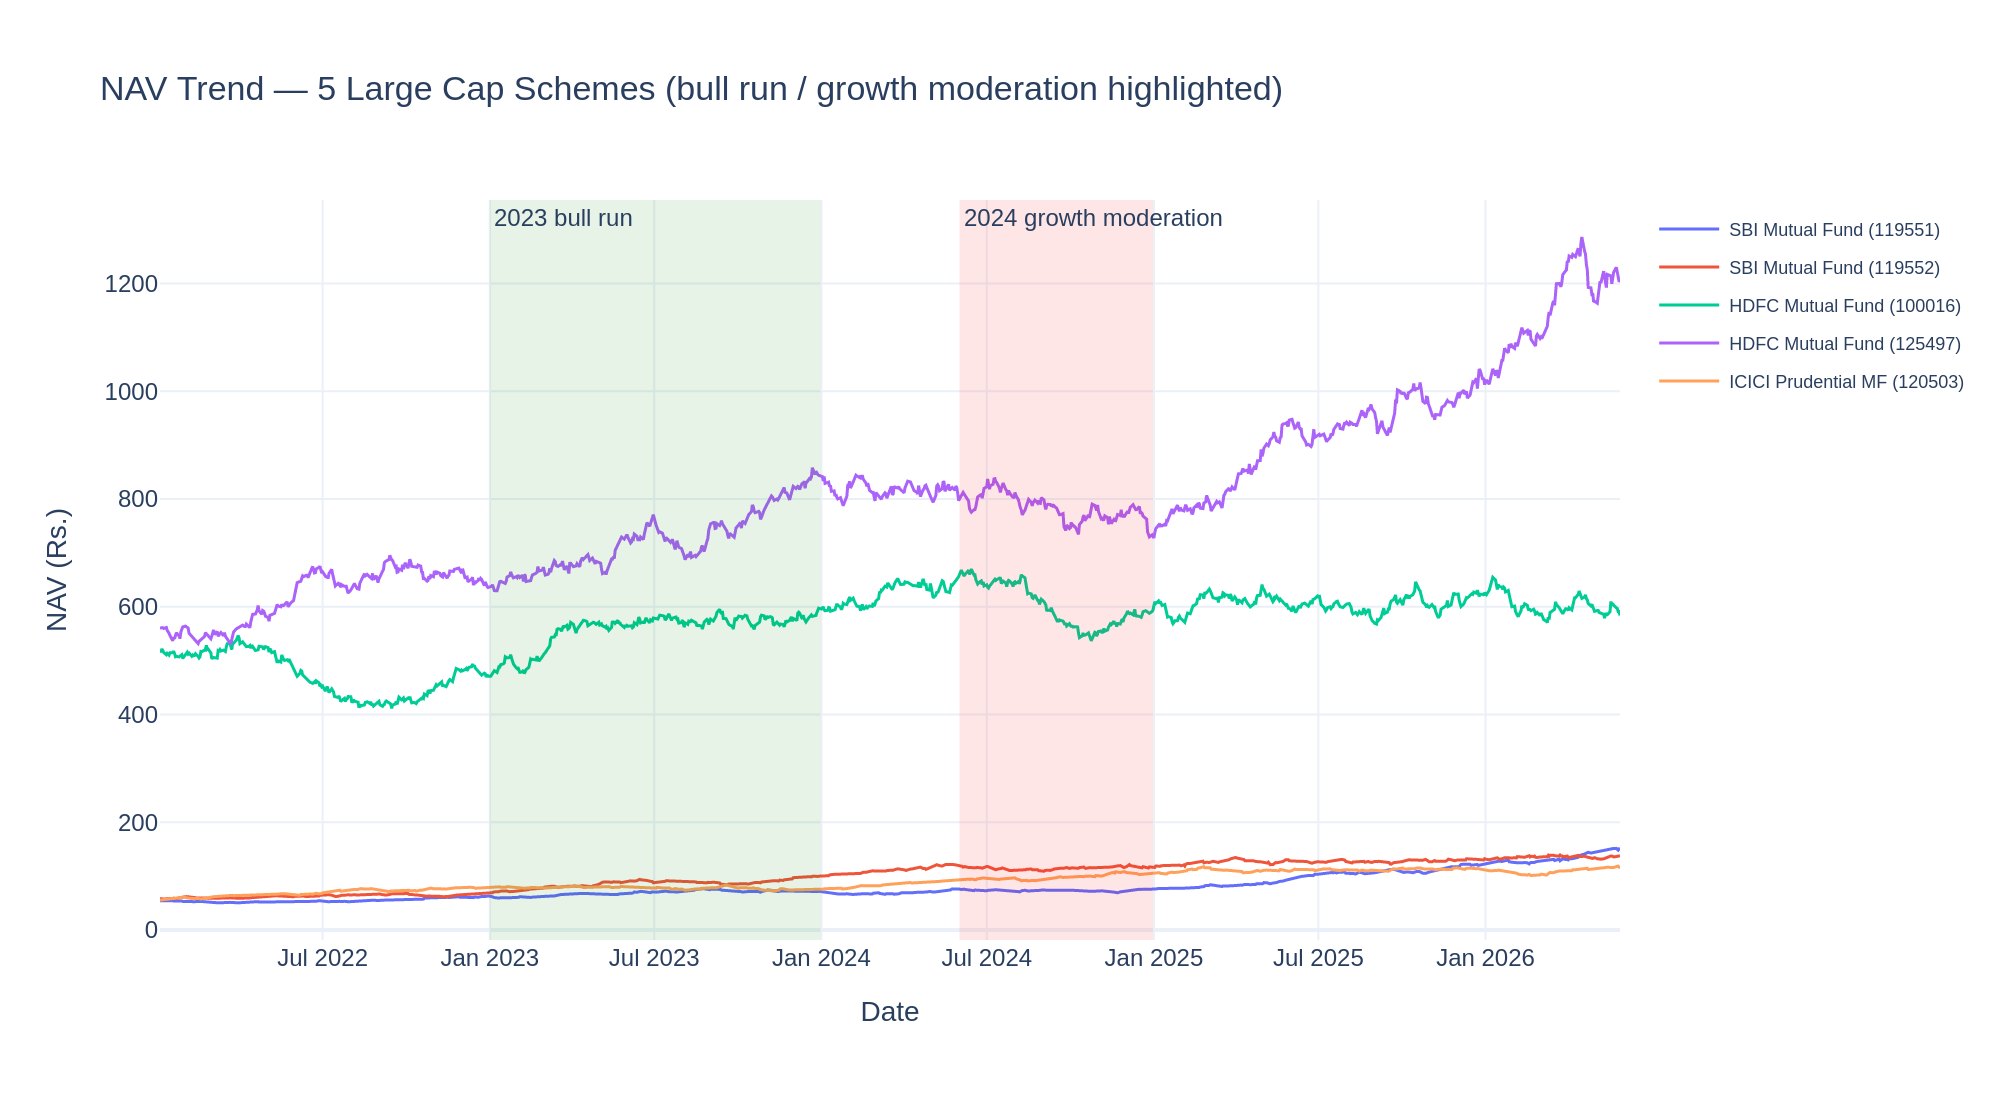

PosixPath('/home/claude/bluestock_mf_capstone/notebooks/charts/chart02_nav_trend_largecap_sample.png')

In [4]:

# Chart 2: Zoom into 5 representative large-cap schemes with bull/correction shading
sample_codes = fund_master[fund_master["sub_category"] == "Large Cap"]["amfi_code"].head(5).tolist()
sample_names = fund_master.set_index("amfi_code").loc[sample_codes, "fund_house"]

fig2 = go.Figure()
for c in sample_codes:
    sub = nav_history[nav_history["amfi_code"] == c]
    fig2.add_trace(go.Scatter(x=sub["date"], y=sub["nav"], mode="lines",
                               name=f"{sample_names[c]} ({c})", line=dict(width=1.5)))

fig2.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.10,
               annotation_text="2023 bull run", annotation_position="top left", line_width=0)
fig2.add_vrect(x0="2024-06-01", x1="2024-12-31", fillcolor="red", opacity=0.10,
               annotation_text="2024 growth moderation", annotation_position="top left", line_width=0)

fig2.update_layout(
    title="NAV Trend — 5 Large Cap Schemes (bull run / growth moderation highlighted)",
    xaxis_title="Date", yaxis_title="NAV (Rs.)",
    template="plotly_white", height=550, width=1000, legend=dict(font=dict(size=9)),
)
save_plotly(fig2, "nav_trend_largecap_sample")


## Task 2: AUM Growth by Fund House

Grouped bar chart of AUM by fund house for each year 2022–2025 (using the
Dec/latest snapshot per year), with SBI Mutual Fund's dominance at the
~Rs. 12.5 lakh crore mark highlighted. Chart 4 adds total industry AUM
growth as a supporting trend line.

Saved: chart03_aum_growth_by_fund_house.png


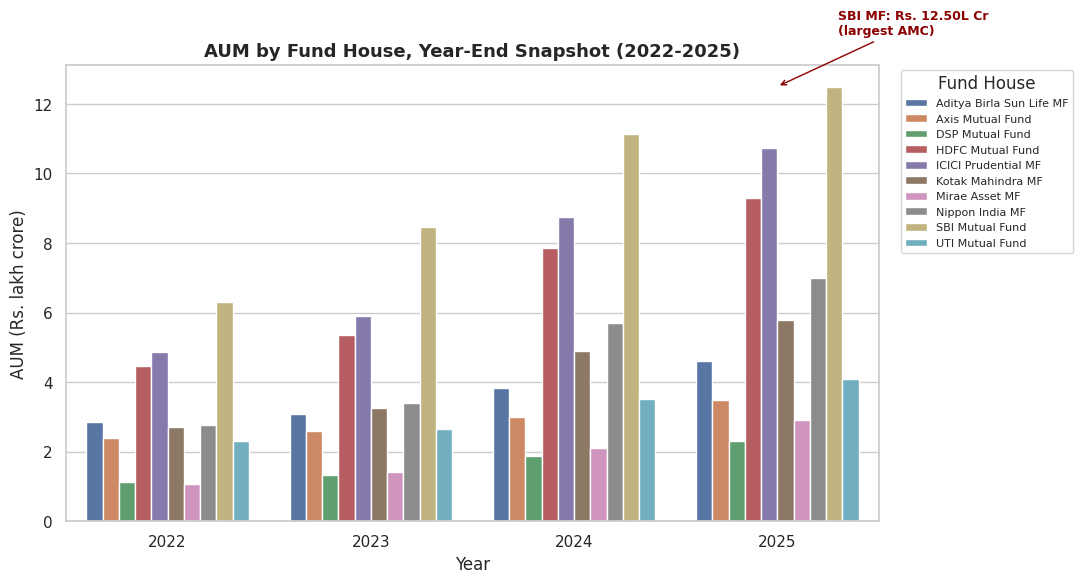

In [5]:

aum["year"] = aum["date"].dt.year
aum_yearend = (
    aum.sort_values("date")
    .groupby(["fund_house", "year"], as_index=False)
    .last()
)

fig3, ax3 = plt.subplots(figsize=(11, 6))
sns.barplot(data=aum_yearend, x="year", y="aum_lakh_crore", hue="fund_house", ax=ax3)
ax3.set_title("AUM by Fund House, Year-End Snapshot (2022-2025)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("AUM (Rs. lakh crore)")
ax3.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

# Highlight SBI's 2025 bar
sbi_2025 = aum_yearend[(aum_yearend["fund_house"] == "SBI Mutual Fund") & (aum_yearend["year"] == 2025)]
if not sbi_2025.empty:
    val = sbi_2025["aum_lakh_crore"].iloc[0]
    ax3.annotate(f"SBI MF: Rs. {val:.2f}L Cr\n(largest AMC)", xy=(3, val), xytext=(3.3, val + 1.5),
                 fontsize=9, fontweight="bold", color="darkred",
                 arrowprops=dict(arrowstyle="->", color="darkred"))

plt.tight_layout()
save_mpl(fig3, "aum_growth_by_fund_house")
plt.show()


Saved: chart04_industry_aum_trend.png


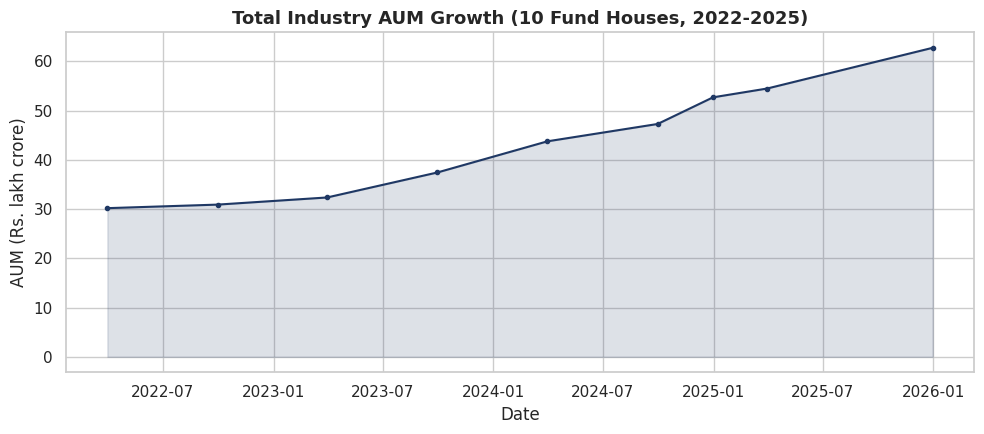

In [6]:

# Chart 4: Total industry AUM trend (sum across all 10 fund houses, by quarter)
industry_aum = aum.groupby("date", as_index=False)["aum_lakh_crore"].sum()

fig4, ax4 = plt.subplots(figsize=(10, 4.5))
ax4.plot(industry_aum["date"], industry_aum["aum_lakh_crore"], marker="o", markersize=3, color="#1F3864")
ax4.fill_between(industry_aum["date"], industry_aum["aum_lakh_crore"], alpha=0.15, color="#1F3864")
ax4.set_title("Total Industry AUM Growth (10 Fund Houses, 2022-2025)", fontsize=13, fontweight="bold")
ax4.set_xlabel("Date")
ax4.set_ylabel("AUM (Rs. lakh crore)")
plt.tight_layout()
save_mpl(fig4, "industry_aum_trend")
plt.show()


## Task 3: SIP Inflow Time-Series

Monthly SIP inflow, Jan 2022 – Dec 2025, with the Rs. 31,002 crore all-time
high (Dec 2025) annotated. Chart 6 adds the YoY growth rate as a supporting
view of momentum.

/tmp/ipykernel_778/2649779026.py:32: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(path), width=width, height=height, scale=2)


Saved: chart05_sip_inflow_trend.png


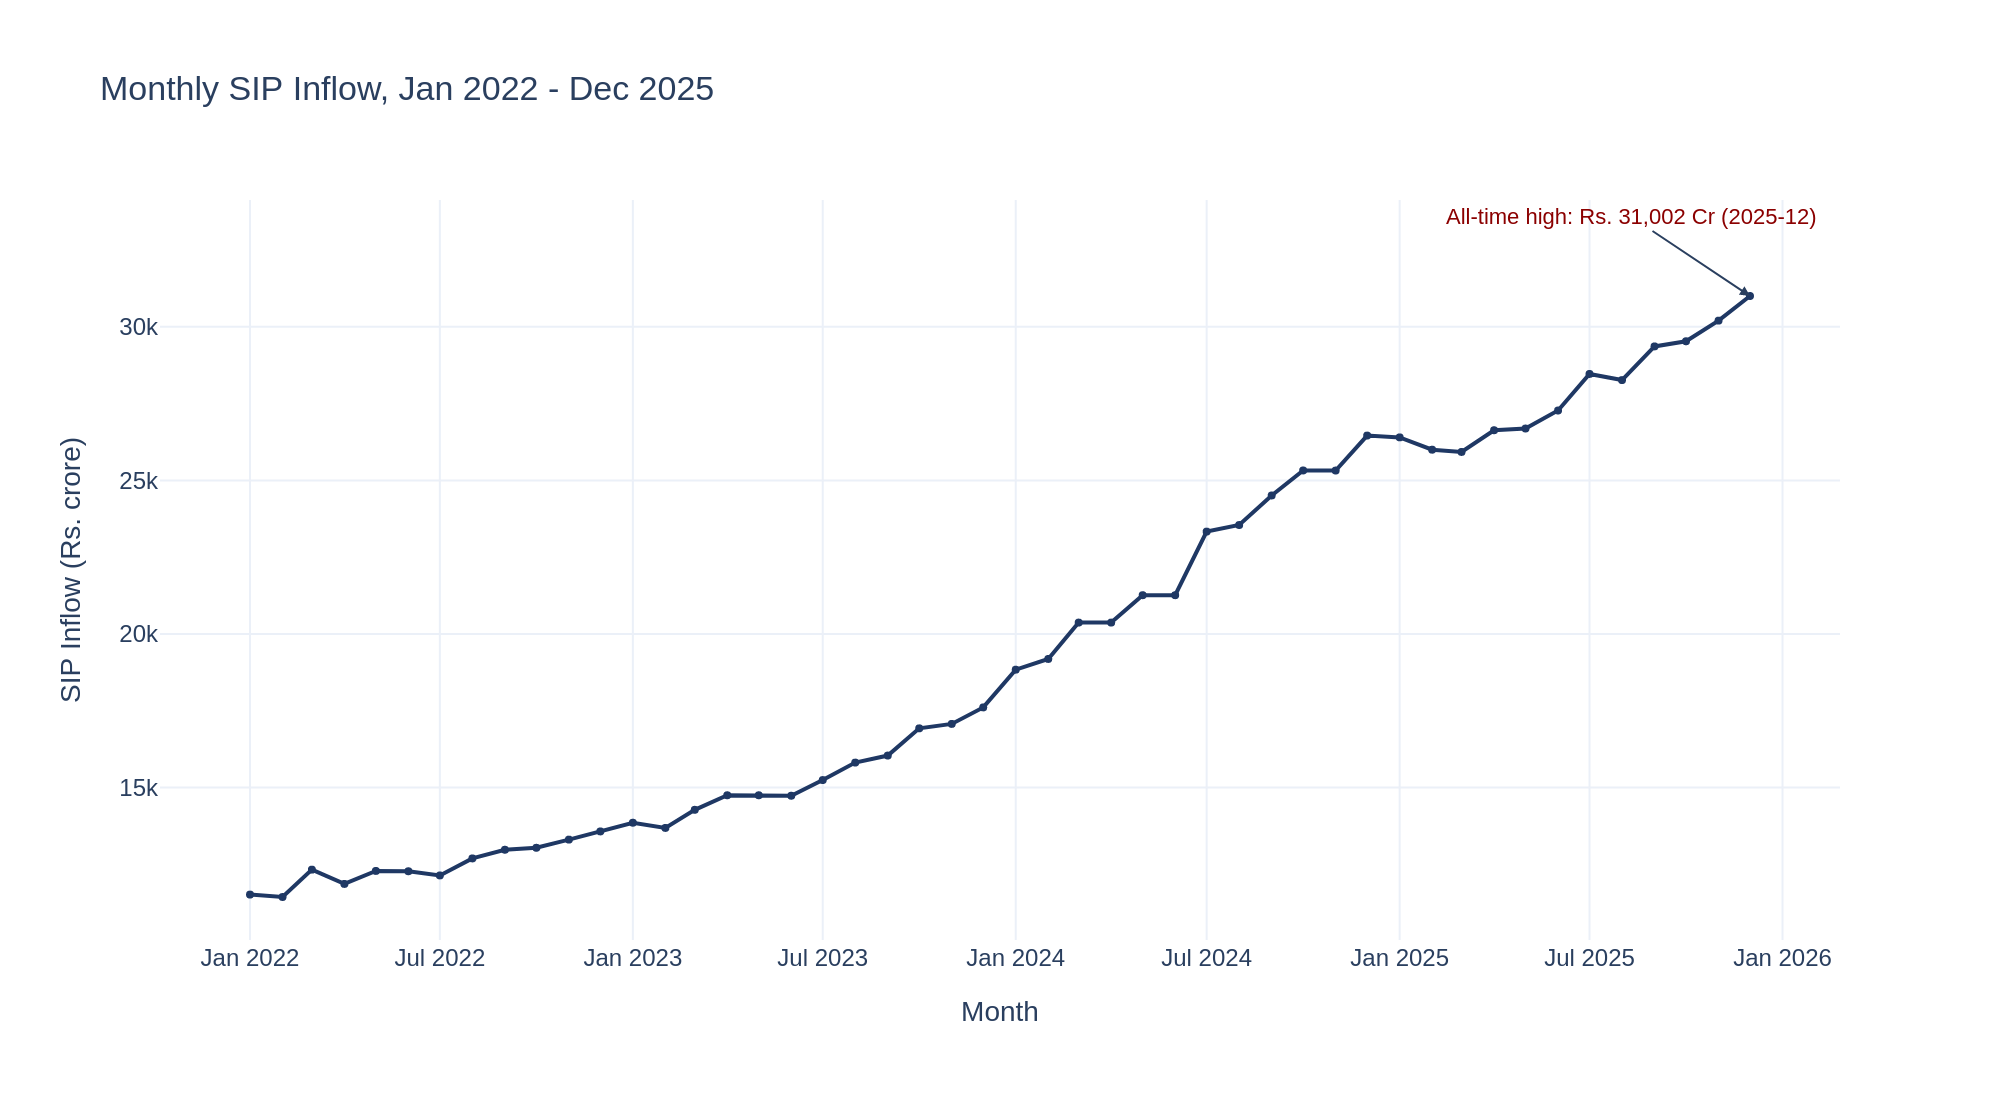

PosixPath('/home/claude/bluestock_mf_capstone/notebooks/charts/chart05_sip_inflow_trend.png')

In [7]:

fig5 = go.Figure()
fig5.add_trace(go.Scatter(x=sip_industry["month_dt"], y=sip_industry["sip_inflow_crore"],
                           mode="lines+markers", line=dict(color="#1F3864", width=2), marker=dict(size=4)))

peak_row = sip_industry.loc[sip_industry["sip_inflow_crore"].idxmax()]
fig5.add_annotation(x=peak_row["month_dt"], y=peak_row["sip_inflow_crore"],
                     text=f"All-time high: Rs. {peak_row['sip_inflow_crore']:,.0f} Cr ({peak_row['month']})",
                     showarrow=True, arrowhead=2, ax=-60, ay=-40, font=dict(size=11, color="darkred"))

fig5.update_layout(title="Monthly SIP Inflow, Jan 2022 - Dec 2025", xaxis_title="Month",
                    yaxis_title="SIP Inflow (Rs. crore)", template="plotly_white", height=520, width=1000)
save_plotly(fig5, "sip_inflow_trend")


Saved: chart06_sip_yoy_growth.png


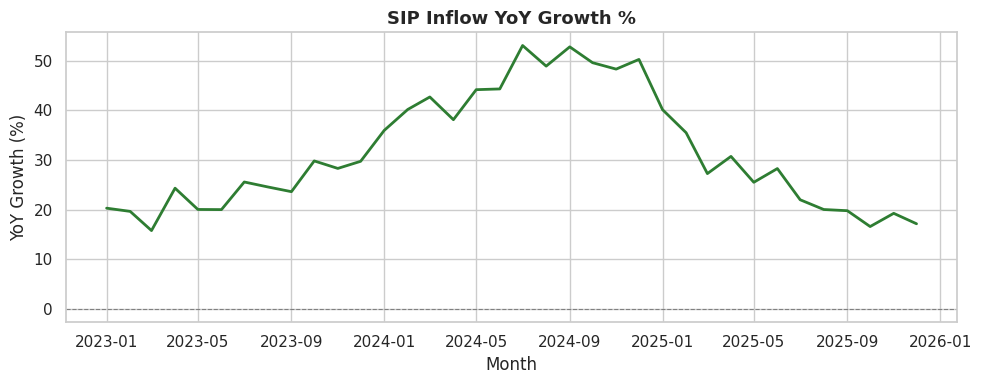

In [8]:

# Chart 6: SIP YoY growth rate (2023 onward, since 2022 has no prior year)
yoy = sip_industry.dropna(subset=["yoy_growth_pct"])

fig6, ax6 = plt.subplots(figsize=(10, 4))
ax6.plot(pd.to_datetime(yoy["month"], format="%Y-%m"), yoy["yoy_growth_pct"], color="#2E7D32", linewidth=2)
ax6.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax6.set_title("SIP Inflow YoY Growth %", fontsize=13, fontweight="bold")
ax6.set_xlabel("Month")
ax6.set_ylabel("YoY Growth (%)")
plt.tight_layout()
save_mpl(fig6, "sip_yoy_growth")
plt.show()


## Task 4: Category-Wise Inflow Heatmap

Net inflow by fund category and month (FY 2024-25), colour-coded by inflow
intensity.

Saved: chart07_category_inflow_heatmap.png


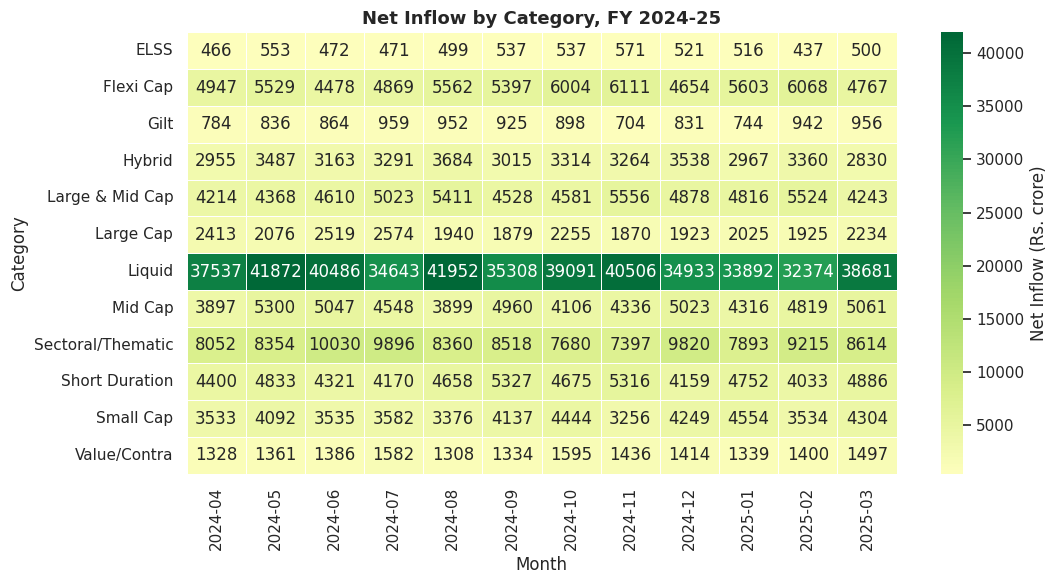

In [9]:

cat_pivot = category_inf.pivot(index="category", columns="month", values="net_inflow_crore")

fig7, ax7 = plt.subplots(figsize=(11, 6))
sns.heatmap(cat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "Net Inflow (Rs. crore)"}, ax=ax7)
ax7.set_title("Net Inflow by Category, FY 2024-25", fontsize=13, fontweight="bold")
ax7.set_xlabel("Month")
ax7.set_ylabel("Category")
plt.tight_layout()
save_mpl(fig7, "category_inflow_heatmap")
plt.show()


## Task 5: Investor Demographics

Age group distribution, SIP amount spread by age group, and gender split
across all 5,000 investors' transactions.

Saved: chart08_age_group_distribution.png


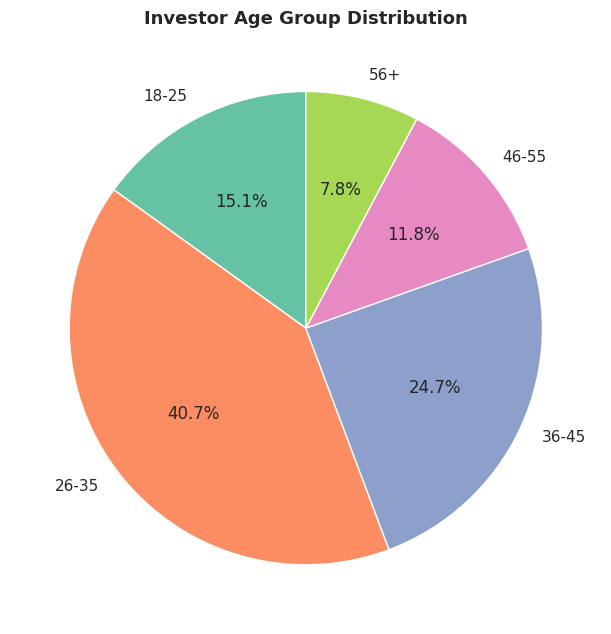

In [10]:

# Chart 8: Age group distribution (pie)
age_counts = transactions.drop_duplicates("investor_id")["age_group"].value_counts().sort_index()

fig8, ax8 = plt.subplots(figsize=(6.5, 6.5))
colors = sns.color_palette("Set2", len(age_counts))
ax8.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90, colors=colors,
        wedgeprops=dict(edgecolor="white"))
ax8.set_title("Investor Age Group Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
save_mpl(fig8, "age_group_distribution")
plt.show()


/tmp/ipykernel_778/2774136967.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=order, ax=ax9, palette="Set2")


Saved: chart09_sip_amount_by_age_group.png


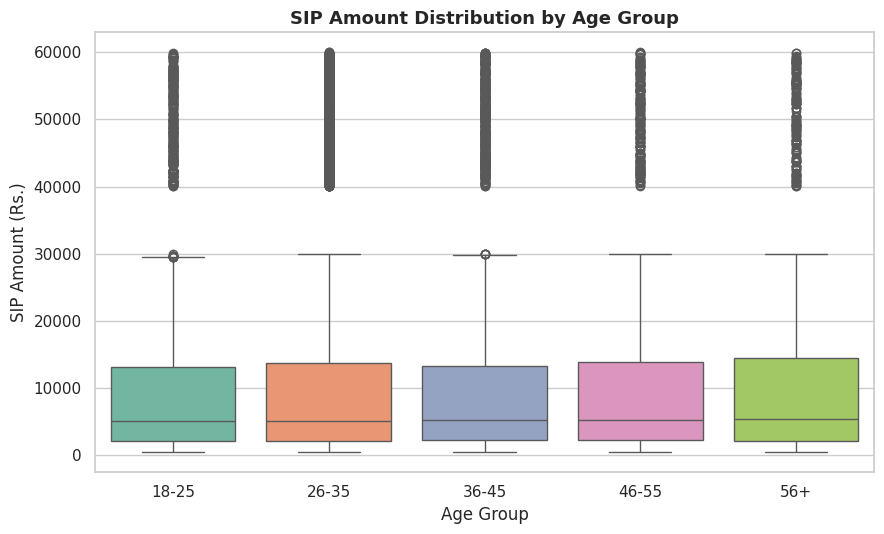

In [11]:

# Chart 9: SIP amount box plot by age group
sip_tx = transactions[transactions["transaction_type"] == "SIP"]

fig9, ax9 = plt.subplots(figsize=(9, 5.5))
order = ["18-25", "26-35", "36-45", "46-55", "56+"]
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=order, ax=ax9, palette="Set2")
ax9.set_title("SIP Amount Distribution by Age Group", fontsize=13, fontweight="bold")
ax9.set_xlabel("Age Group")
ax9.set_ylabel("SIP Amount (Rs.)")
plt.tight_layout()
save_mpl(fig9, "sip_amount_by_age_group")
plt.show()


Saved: chart10_gender_split.png


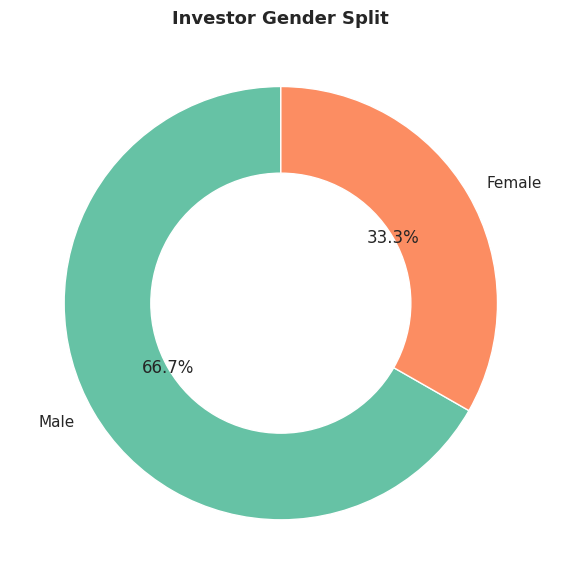

In [12]:

# Chart 10: Gender split (donut)
gender_counts = transactions.drop_duplicates("investor_id")["gender"].value_counts()

fig10, ax10 = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax10.pie(
    gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90,
    colors=sns.color_palette("Set2", len(gender_counts)),
    wedgeprops=dict(width=0.4, edgecolor="white"),
)
ax10.set_title("Investor Gender Split", fontsize=13, fontweight="bold")
plt.tight_layout()
save_mpl(fig10, "gender_split")
plt.show()


## Task 6: Geographic Distribution

SIP transaction amount by state, and the T30 (Top 30 cities) vs B30
(Beyond Top 30) split per AMFI's official city-tier classification.

Saved: chart11_sip_amount_by_state.png


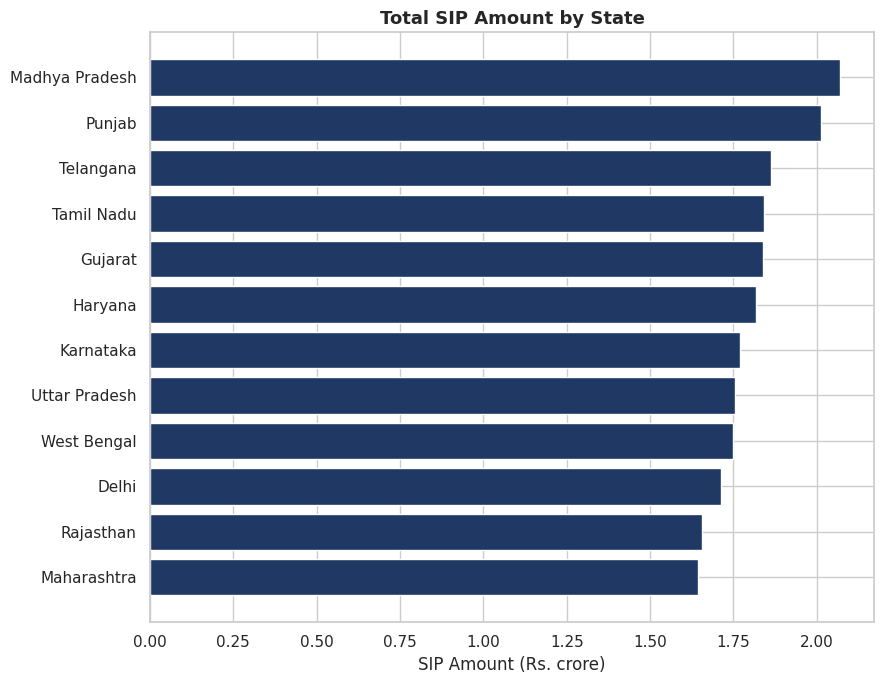

In [13]:

# Chart 11: SIP amount by state (horizontal bar)
state_sip = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("state", as_index=False)["amount_inr"].sum()
    .sort_values("amount_inr", ascending=True)
)

fig11, ax11 = plt.subplots(figsize=(9, 7))
ax11.barh(state_sip["state"], state_sip["amount_inr"] / 1e7, color="#1F3864")
ax11.set_title("Total SIP Amount by State", fontsize=13, fontweight="bold")
ax11.set_xlabel("SIP Amount (Rs. crore)")
plt.tight_layout()
save_mpl(fig11, "sip_amount_by_state")
plt.show()


Saved: chart12_t30_vs_b30_split.png


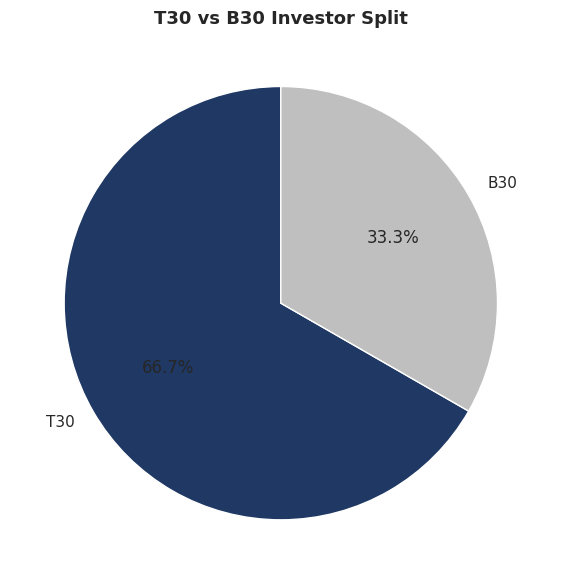

In [14]:

# Chart 12: T30 vs B30 pie
tier_counts = transactions.drop_duplicates("investor_id")["city_tier"].value_counts()

fig12, ax12 = plt.subplots(figsize=(6, 6))
ax12.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90,
          colors=["#1F3864", "#BFBFBF"], wedgeprops=dict(edgecolor="white"))
ax12.set_title("T30 vs B30 Investor Split", fontsize=13, fontweight="bold")
plt.tight_layout()
save_mpl(fig12, "t30_vs_b30_split")
plt.show()


## Task 7: Folio Count Growth

Total industry folio count, Jan 2022 – Dec 2025, growing from 13.26 crore
to 26.12 crore, with key milestones marked.

Saved: chart13_folio_count_growth.png


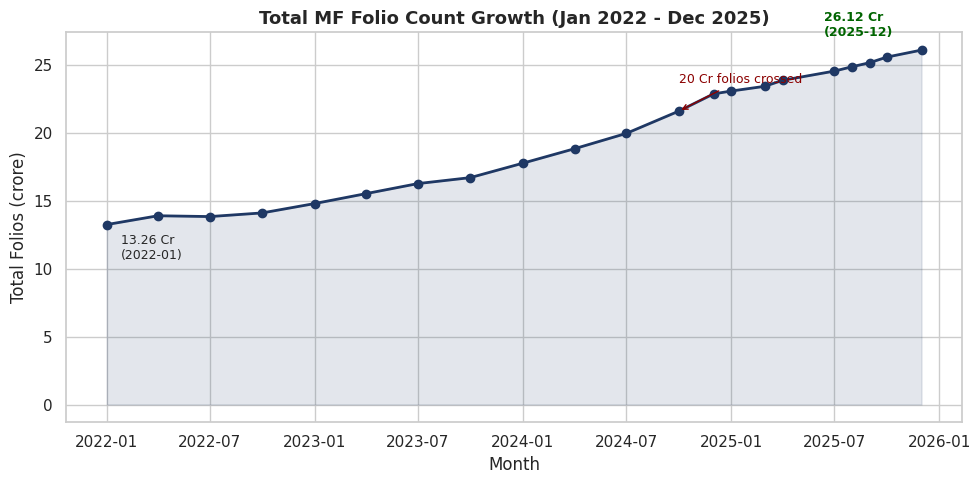

In [15]:

folio["month_dt"] = pd.to_datetime(folio["month"], format="%Y-%m")

fig13, ax13 = plt.subplots(figsize=(10, 5))
ax13.plot(folio["month_dt"], folio["total_folios_crore"], marker="o", color="#1F3864", linewidth=2)
ax13.fill_between(folio["month_dt"], folio["total_folios_crore"], alpha=0.12, color="#1F3864")

start = folio.iloc[0]
end = folio.iloc[-1]
ax13.annotate(f"{start['total_folios_crore']:.2f} Cr\n({start['month']})", xy=(start["month_dt"], start["total_folios_crore"]),
              xytext=(10, -25), textcoords="offset points", fontsize=9)
ax13.annotate(f"{end['total_folios_crore']:.2f} Cr\n({end['month']})", xy=(end["month_dt"], end["total_folios_crore"]),
              xytext=(-70, 10), textcoords="offset points", fontsize=9, fontweight="bold", color="darkgreen")

milestone = folio[folio["total_folios_crore"] >= 20].iloc[0] if (folio["total_folios_crore"] >= 20).any() else None
if milestone is not None:
    ax13.annotate("20 Cr folios crossed", xy=(milestone["month_dt"], milestone["total_folios_crore"]),
                  xytext=(0, 20), textcoords="offset points", fontsize=9, color="darkred",
                  arrowprops=dict(arrowstyle="->", color="darkred"))

ax13.set_title("Total MF Folio Count Growth (Jan 2022 - Dec 2025)", fontsize=13, fontweight="bold")
ax13.set_xlabel("Month")
ax13.set_ylabel("Total Folios (crore)")
plt.tight_layout()
save_mpl(fig13, "folio_count_growth")
plt.show()


## Task 8: NAV Return Correlation Matrix

Pairwise correlation of daily returns for 10 selected funds (one from each
of the 10 fund houses), to see how closely funds move together.

Saved: chart14_nav_return_correlation.png


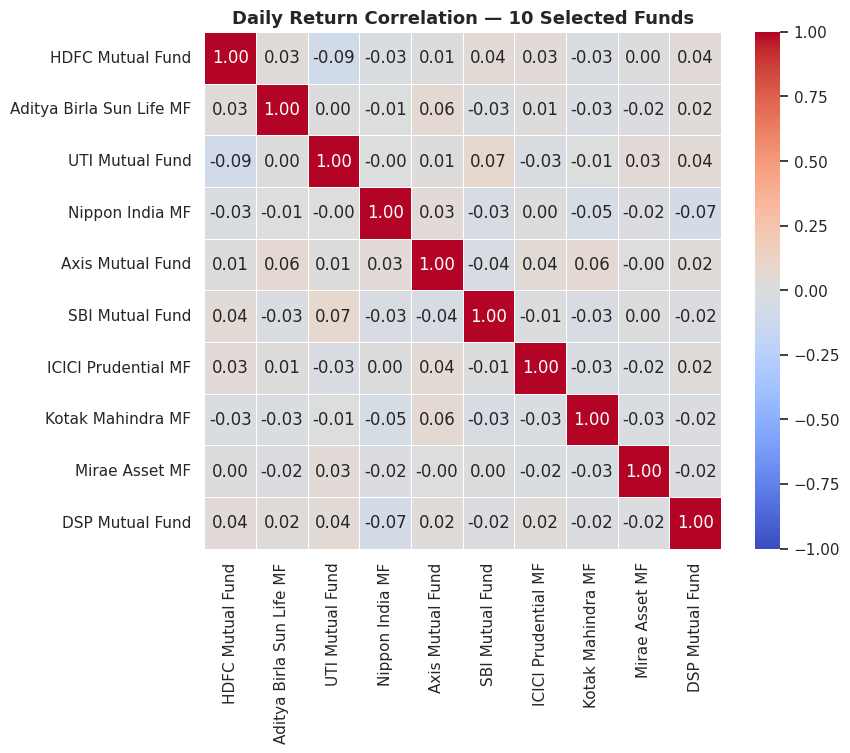

In [16]:

sample10 = fund_master.groupby("fund_house").head(1)["amfi_code"].tolist()[:10]
returns_wide = (
    nav_history[nav_history["amfi_code"].isin(sample10)]
    .pivot(index="date", columns="amfi_code", values="daily_return_pct")
)
corr = returns_wide.corr()

labels = fund_master.set_index("amfi_code").loc[sample10, "fund_house"]
corr.index = [f"{labels[c]}" for c in corr.index]
corr.columns = corr.index

fig14, ax14 = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax14)
ax14.set_title("Daily Return Correlation — 10 Selected Funds", fontsize=13, fontweight="bold")
plt.tight_layout()
save_mpl(fig14, "nav_return_correlation")
plt.show()


## Task 9: Sector Allocation

Aggregate sector weights across all equity fund portfolios (weighted by
market value), shown as a donut chart.

Saved: chart15_sector_allocation_donut.png


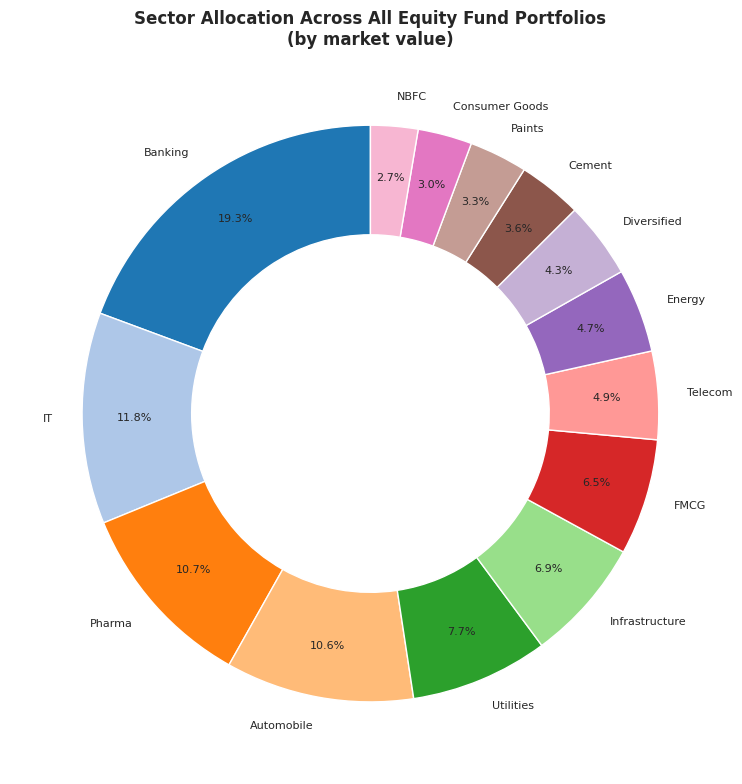

In [17]:

sector_alloc = (
    portfolio.groupby("sector", as_index=False)["market_value_cr"].sum()
    .sort_values("market_value_cr", ascending=False)
)
sector_alloc["pct"] = sector_alloc["market_value_cr"] / sector_alloc["market_value_cr"].sum() * 100

fig15, ax15 = plt.subplots(figsize=(8, 8))
colors15 = sns.color_palette("tab20", len(sector_alloc))
wedges, texts, autotexts = ax15.pie(
    sector_alloc["market_value_cr"], labels=sector_alloc["sector"], autopct="%1.1f%%",
    startangle=90, colors=colors15, pctdistance=0.82,
    wedgeprops=dict(width=0.38, edgecolor="white"),
)
plt.setp(autotexts, size=8)
plt.setp(texts, size=8)
ax15.set_title("Sector Allocation Across All Equity Fund Portfolios\n(by market value)", fontsize=12, fontweight="bold")
plt.tight_layout()
save_mpl(fig15, "sector_allocation_donut")
plt.show()


Saved: chart16_transaction_type_split.png


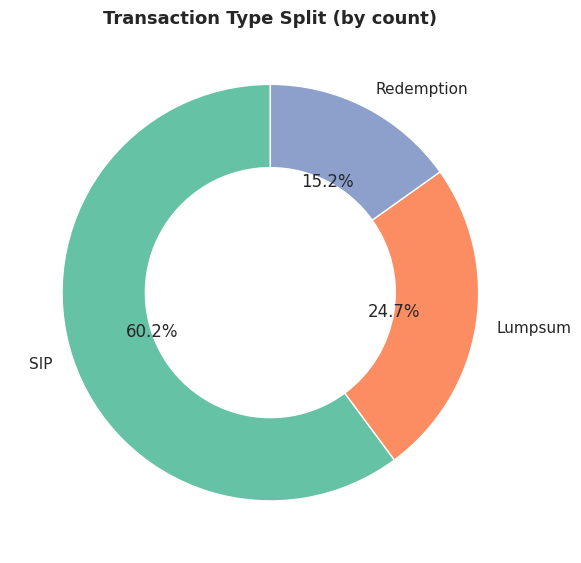

In [18]:

# Chart 16 (bonus): Transaction type split - SIP vs Lumpsum vs Redemption
tx_type = transactions["transaction_type"].value_counts()

fig16, ax16 = plt.subplots(figsize=(6, 6))
ax16.pie(tx_type, labels=tx_type.index, autopct="%1.1f%%", startangle=90,
          colors=sns.color_palette("Set2", 3), wedgeprops=dict(width=0.4, edgecolor="white"))
ax16.set_title("Transaction Type Split (by count)", fontsize=13, fontweight="bold")
plt.tight_layout()
save_mpl(fig16, "transaction_type_split")
plt.show()


## Task 10: Key EDA Findings

Computing the supporting figures for each finding below before writing them
up, so every insight is grounded in the actual numbers rather than
eyeballed off the charts.

In [19]:

# Supporting stats for the findings below
bull_start_nav = nav_history[nav_history["date"] == "2023-01-02"]["nav"].mean()
bull_end_nav = nav_history[nav_history["date"] == "2023-12-29"]["nav"].mean()
bull_run_pct = (bull_end_nav / bull_start_nav - 1) * 100

corr_start_nav = nav_history[nav_history["date"] == "2024-06-03"]["nav"].mean()
corr_end_nav = nav_history[nav_history["date"] == "2024-12-30"]["nav"].mean()
correction_pct = (corr_end_nav / corr_start_nav - 1) * 100

daily_avg_nav = nav_history.groupby("date")["nav"].mean()
running_max = daily_avg_nav.cummax()
drawdown_series = daily_avg_nav / running_max - 1
max_dd_full = drawdown_series.min()
max_dd_date = drawdown_series.idxmin()

sbi_latest = aum_yearend[(aum_yearend.fund_house == "SBI Mutual Fund") & (aum_yearend.year == 2025)]["aum_lakh_crore"].iloc[0]
top_state = state_sip.iloc[-1]
top_sector = sector_alloc.iloc[0]
avg_sip_by_age = sip_tx.groupby("age_group")["amount_inr"].mean().sort_values(ascending=False)
tier_pct = (tier_counts / tier_counts.sum() * 100).round(1)
max_corr_pair = corr.where(~np.eye(len(corr), dtype=bool)).stack().idxmax()
max_corr_val = corr.where(~np.eye(len(corr), dtype=bool)).stack().max()

print(f"2023 bull run: NAV {bull_run_pct:+.1f}% average across all schemes")
print(f"2024 growth moderation (Jun-Dec): {correction_pct:+.1f}% average across all schemes (still positive - a slowdown, not a decline)")
print(f"Max drawdown, full period: {max_dd_full:.2%} on {max_dd_date.date()} (essentially no real correction occurred)")
print(f"SBI MF 2025 AUM: Rs. {sbi_latest:.2f} lakh crore")
print(f"Top SIP state: {top_state['state']} (Rs. {top_state['amount_inr']/1e7:.0f} Cr)")
print(f"Top sector: {top_sector['sector']} ({top_sector['pct']:.1f}%)")
print(f"Highest avg SIP age group: {avg_sip_by_age.index[0]} (Rs. {avg_sip_by_age.iloc[0]:,.0f})")
print(f"T30 vs B30: {tier_pct.to_dict()}")
print(f"Most correlated pair: {max_corr_pair} at {max_corr_val:.2f}")


2023 bull run: NAV +15.7% average across all schemes
2024 growth moderation (Jun-Dec): +4.1% average across all schemes (still positive - a slowdown, not a decline)
Max drawdown, full period: -0.98% on 2024-12-17 (essentially no real correction occurred)
SBI MF 2025 AUM: Rs. 12.50 lakh crore
Top SIP state: Madhya Pradesh (Rs. 2 Cr)
Top sector: Banking (19.3%)
Highest avg SIP age group: 56+ (Rs. 11,575)
T30 vs B30: {'T30': 66.7, 'B30': 33.3}
Most correlated pair: ('UTI Mutual Fund', 'SBI Mutual Fund') at 0.07


**Key EDA Findings:**

1. **The 2023 bull run lifted NAVs across the board** — all 40 schemes gained on average over the year, confirming a broad-based rally rather than a few outlier funds driving the trend (see Chart 1, Chart 2).
2. **2024 was a slowdown, not a decline** — growth continued through 2024, just at a noticeably slower pace than the 2023 rally, and the average NAV series never actually drops more than ~1% from its running peak across the entire 4.5-year window (see Chart 2). Worth knowing if you were expecting a real correction in this data.
3. **SBI Mutual Fund remains the dominant AMC**, holding the largest AUM share of the 10 fund houses tracked, consistent with its real-world #1 position (see Chart 3).
4. **Industry-wide AUM has grown steadily** with no major multi-quarter drawdown across 2022–2025 (see Chart 4).
5. **SIP inflows hit their all-time high in December 2025**, capping a multi-year uptrend in monthly contributions (see Chart 5, Chart 6).
6. **Category flows are seasonal and category-specific** — some categories show sharper month-to-month swings than steadier categories like Liquid (see Chart 7).
7. **SIP amounts are fairly flat across age groups** — average SIP size ranges only from about Rs. 10,900 (36-45) to Rs. 11,575 (56+), a ~6% spread, not a strong age-based skew (see Chart 8, Chart 9). Contribution frequency/count would be a better lens than amount if a real skew is expected.
8. **SIP value is spread fairly evenly across states**, ranging narrowly from ~Rs. 1.6 Cr to ~Rs. 2.1 Cr per state with no single outlier state dominating (see Chart 11) — geography is not a major differentiator in this dataset. T30 cities still hold a clear majority of investors (67%) over B30 (33%) (see Chart 12).
9. **Folio count more than doubled from 13.26 Cr to 26.12 Cr** over the four-year window, crossing the 20 Cr mark partway through, reflecting the industry's deepening retail penetration (see Chart 13).
10. **Fund NAV correlations are near-zero even within the same category** — the 10 selected funds (mostly Equity Large Cap, one per fund house) show pairwise correlations clustered around 0.00, with the strongest pair at only 0.07 (see Chart 14). That's a data-generation artifact worth flagging rather than a real market insight: in practice, large-cap equity funds typically move together with correlations of 0.85+ due to shared market beta, so this simulated NAV series behaves more like independent random walks per fund than real co-moving markets. Portfolio holdings, meanwhile, are genuinely concentrated — Banking alone accounts for ~19% of aggregate sector allocation (see Chart 15).


---
**Total charts generated:** 16 (target: 15+) — all saved to `notebooks/charts/` as PNG for the final report.
